# Integration of scRNA-seq

During the analysis of scRNA-seq data, we normally have several samples.The main challenge that arises when dealing with multiple samples are the **batch effects**. Batch effects are changes in measured expression levels which can arise due to different reasons. Removing these effects is crucial to allow the joint analysis focussing on finding common structure in the data. In order to remove these batch effects, there are different type of methods, each one solving the issue using specific approaches.

In the DoTools, we included common integration methods used in sc/snRNA-seq data analysis, including: **CCA** (Seurat) and **Harmony** which perform well for simple batch correction tasks and **scVI**, **scANVI** and **Scanorama**, which perform well in more complex data integration tasks.


In [1]:
!wget "https://ndownloader.figshare.com/files/52854605" -O /Users/david/Downloads/adata.h5ad

/Users/david/Downlo 100%[===================>]   3.28G  12.0MB/s    in 3m 49s  

2026-01-20 12:47:30 (14.6 MB/s) - ‘/Users/david/Downloads/adata.h5ad’ saved [3516946145/3516946145]



In [1]:
# Set Up
import dotools_py as do
import scanpy as sc
import session_info

adata = do.io.read_h5ad("/Users/david/Downloads/adata.h5ad")  # Contains two different datasets
adata.X = adata.layers["logcounts"].copy()
adata

2026-03-11 21:11:26,665 - Jupyter enviroment detected. Using "inline" backend


AnnData object with n_obs × n_vars = 64845 × 25425
    obs: 'sample', 'condition', 'Experiment', 'leiden1_5', 'autoAnnot', 'annotation', 'leiden5', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'batch', 'age'
    var: 'GeneSymbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'age_colors', 'annotation_colors', 'autoAnnot_colors', 'batch_colors', 'condition_colors', 'hvg', 'leiden1_5', 'leiden1_5_colors', 'leiden5', 'leiden5_colors', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'logcounts'
    obsp: 'connectivities', 'distances'

To perform data integration, we first compute the highly variable genes. This allows both to improve the biological signal recovery and computational performance. This is important, because most of the genes in scRNA-seq are lowly expressed, uninformative across cells or dominated by technical noise.

In [2]:
sc.pp.highly_variable_genes(adata, batch_key='batch') # Detect HVGs shared across samples
adata.var["highly_variable"].value_counts()

extracting highly variable genes
    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


highly_variable
False    21748
True      3677
Name: count, dtype: int64

As we can observe, we will use 3,677 highly variable genes instead of the 22,536 genes that we have in our object.
After the selection of HVGs we can proceed with the integration.

## Unintegrated

We first will compute the UMAP embeddings without performing integration using PCA.

In [5]:
%%time
adata_unintegrated = adata.copy()
sc.pp.pca(adata_unintegrated)
do.tl.integrate_data(adata_unintegrated, batch_key="batch", hvg_batch=True, integration_method="pca")

computing PCA
    with n_comps=50
    finished (0:00:03)
2026-03-11 17:46:31,944 - Computing HVGs
extracting highly variable genes
    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    with n_comps=50
    finished (0:00:13)
2026-03-11 17:46:50,038 - Finding neighbors
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)
2026-03-11 17:46:52,954 - Run UMAP
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:23)
2026-03-11 17:47:16,111 - Clustering cells using Leiden (resolution 0.3)
running Leiden clustering
    finished: found 19 clusters and added
    'leiden', the cluster labels (adata.obs, categorical

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


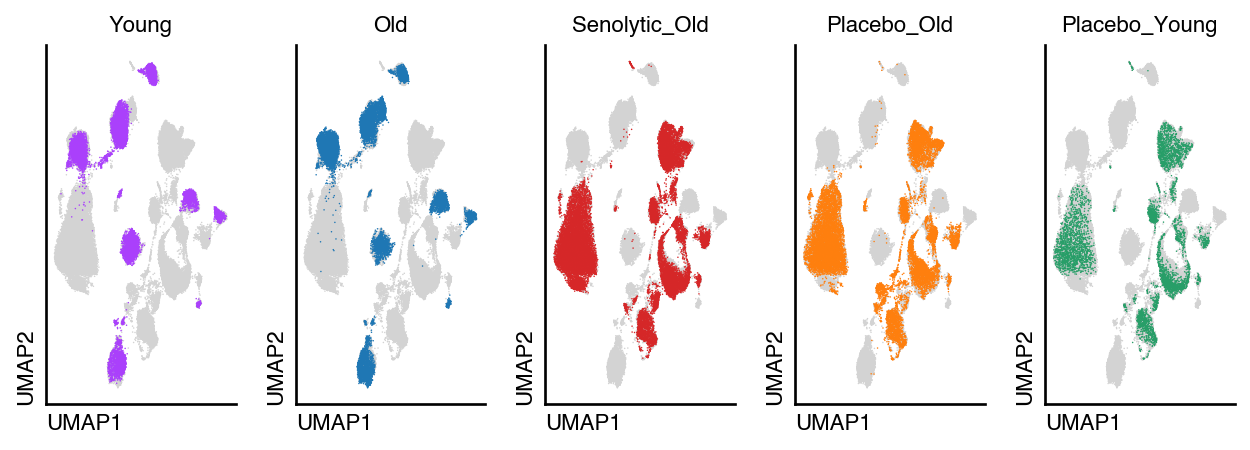

In [13]:
do.pl.split_embedding(adata_unintegrated, "condition",  figsize=(8, 3), ncols=5,  title_fontproperties={"size": 10},  path="/Users/david/Downloads", filename="UMAP_unintegrated.pdf")

# BBKNN
BBKNN integration compute the neighbors within batches and connects then across batches, therefore, no embedding is generated and we use directly the PCA embedding.


In [3]:
%%time
adata_bbknn = adata.copy()
sc.pp.pca(adata_bbknn, use_highly_variable=True)
do.tl.integrate_data(adata_bbknn, batch_key="batch", hvg_batch=False, integration_method="pca", bbknn=True)

computing PCA
    with n_comps=50
    finished (0:00:03)
2026-03-11 21:11:46,004 - Computing HVGs
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    with n_comps=50
    finished (0:00:30)
2026-03-11 21:12:21,118 - Finding neighbors
2026-03-11 21:12:21,119 - Computing neighbors with BBKNN
computing batch balanced neighbors
	finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:08)
2026-03-11 21:12:32,829 - Run UMAP
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:59)
2026-03-11 21:13:32,718 - Clustering cells using Leiden (resolution 0.3)
running Leiden clustering
    finished: found 10 cluste

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


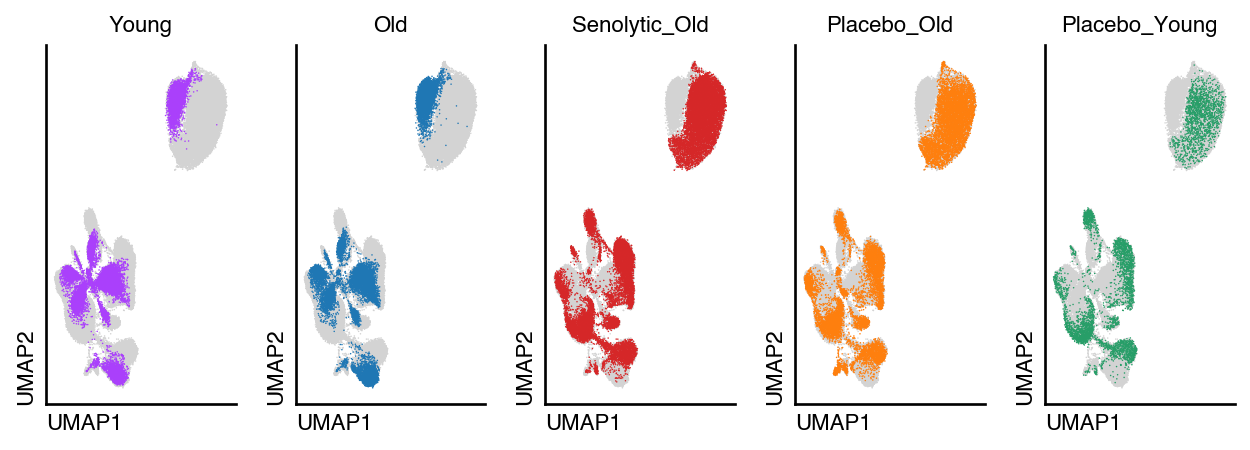

In [4]:
do.pl.split_embedding(adata_bbknn, "condition",  figsize=(8, 3), ncols=5,  title_fontproperties={"size": 10},  path="/Users/david/Downloads", filename="UMAP_BBKNN.pdf")



## Harmony
In this method, after performing the selection of HVGs, we perform dimensionality reduction, like Principal Component Analysis (PCA). Harmony performs integration by adjusting cell embeddings (typically PCA components) so that cells from different batches align while preserving underlying biological structure. The quality of these embeddings depends heavily on which genes are used to generate them.

In [14]:
%%time
adata_harmony = adata.copy()
do.tl.integrate_data(adata_harmony, batch_key="batch", hvg_batch=True, integration_method="harmony")

2026-03-11 17:49:07,342 - Computing HVGs
extracting highly variable genes
    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    with n_comps=50
    finished (0:00:12)
2026-03-11 17:49:24,787 - Integration using Harmony
	Initialization is completed.
	Completed 1 / 150 iteration(s).
	Completed 2 / 150 iteration(s).
	Completed 3 / 150 iteration(s).
	Completed 4 / 150 iteration(s).
	Completed 5 / 150 iteration(s).
	Completed 6 / 150 iteration(s).
	Completed 7 / 150 iteration(s).
	Completed 8 / 150 iteration(s).
Reach convergence after 8 iteration(s).
2026-03-11 17:49:55,631 - Finding neighbors
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:03)
2026-03-11 17:49:58,636 - Run UM

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


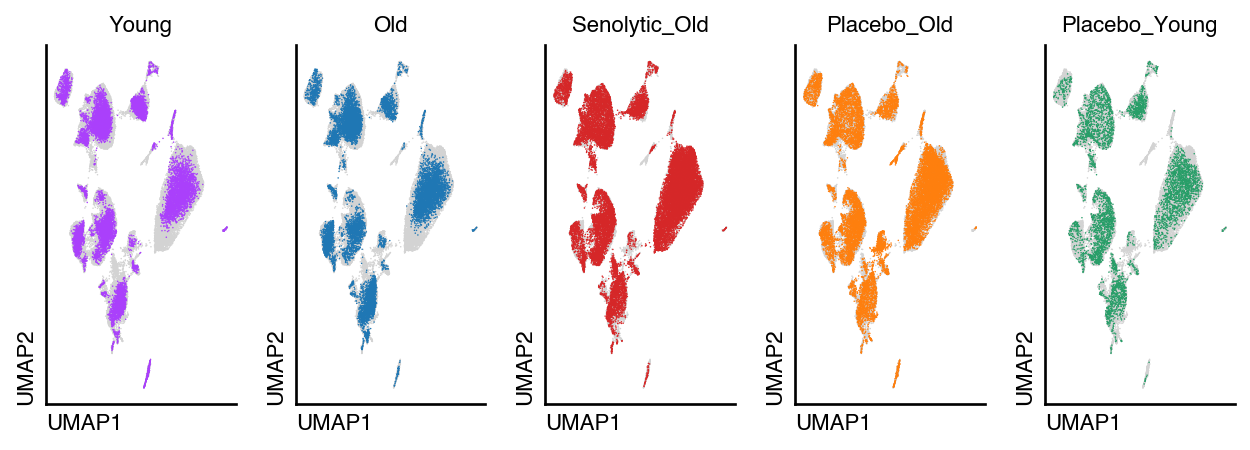

In [16]:
do.pl.split_embedding(adata_harmony, "condition",  figsize=(8, 3), ncols=5,  title_fontproperties={"size": 10},  path="/Users/david/Downloads", filename="UMAP_Harmony.pdf")

In [17]:
adata_harmony.obsm.keys()

KeysView(AxisArrays with keys: X_scVI, X_umap, X_harmony)

After performing integration with Harmony, we have a new representation in `adata.obsm` called **X_harmony**, which contains the batch corrected representation of the data. To perform re-clustering, there are two different approaches: use this representation to find the closest cell neighbors, or re-compute the batch corrected embedding after selecting the cell type or cluster of interest.

## Scanorama
In this method, integration of single-cell datasets is performed by matching biologically similar cells across batches and then computing a non-linear correction that aligns the datasets into a shared low-dimensional space. The core idea is panoramic stitching: identify overlaps between datasets and merge them pairwise, propagating the alignment globally.

In [5]:
%%time
adata_scanorama = adata.copy()
do.tl.integrate_data(adata_scanorama, batch_key="batch", hvg_batch=True, integration_method="scanorama")

2026-03-11 21:14:18,087 - Computing HVGs
extracting highly variable genes
    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    with n_comps=50
    finished (0:00:13)
2026-03-11 21:14:35,783 - Integration using Scanorama
[[0.         0.00031328 0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.        ]
 [0.         0.         0.         0.         0.         0.
  0. 

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


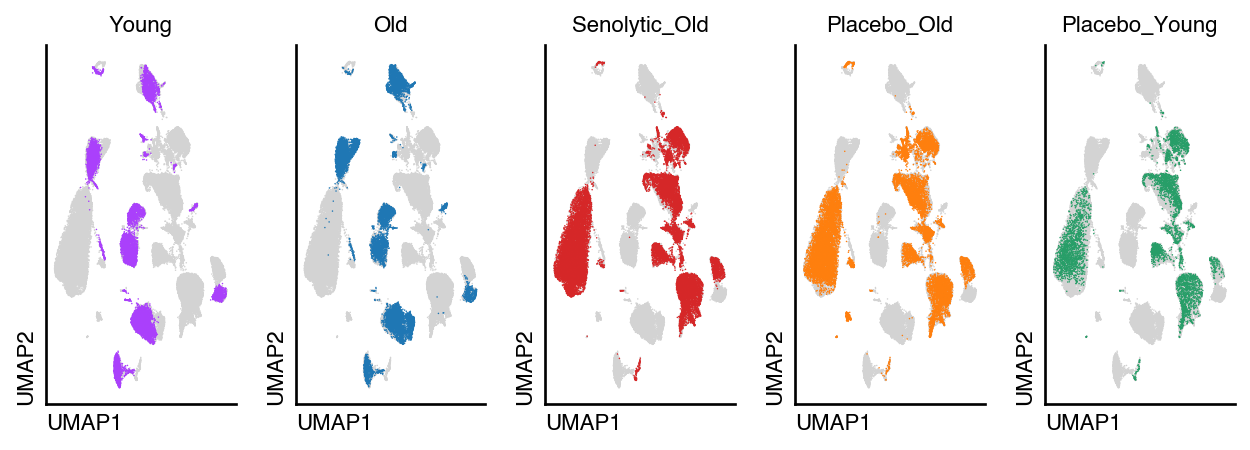

In [24]:
do.pl.split_embedding(adata_scanorama, "condition",  figsize=(8, 3), ncols=5,  title_fontproperties={"size": 10},  path="/Users/david/Downloads", filename="UMAP_Scanorama.pdf")

In [25]:
adata_scanorama.obsm.keys()

KeysView(AxisArrays with keys: X_scVI, X_umap, X_scanorama)

After performing integration with Scanorama, we have a new representation in `adata.obsm` called **X_scanorama**, which contains the batch corrected representation of the data. To perform re-clustering, there are two different approaches: use this representation to find the closest cell neighbors, or re-compute the batch corrected embedding after selecting the cell type or cluster of interest. In our case, we use the second approach in `dotools_py.tl.reclustering`.

## Seurat CCA
The canonical correlation analysis (CCA) is designed to correct batch effects and align shared biological structure across multiple single-cell datasets while preserving meaningful biological variation. CCA is applied to pairs of datasets to find linear combinations of genes (canonical vectors) that are maximally correlated between datasets. These canonical components represent shared sources of biological variation across batches. Using the CCA space, Seurat identifies anchors—pairs of cells from different datasets that are mutual nearest neighbors in the shared low-dimensional space. Anchors serve as correspondences between datasets and encode how datasets should be aligned. Anchors are  then filtered to remove weak or ambiguous matches and are weighted based on similarity. This improves robustness and prevents overcorrection.

Between Seurat v4 and v5 there was a change on how it is performed. In version 4, dimensionality reduction was performed after generated a CCA embedding but in version 5, dimensionality reduction is performed before. This help reducing the computation time, we will use v5 to speed up the analysis.

In [22]:
%%time
adata_cca5 = adata.copy()
do.tl.integrate_data(adata_cca5, batch_key="batch", hvg_batch=True, integration_method="cca5")

2026-03-11 17:53:00,813 - Computing HVGs
extracting highly variable genes
    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    with n_comps=50
    finished (0:00:13)
2026-03-11 17:53:18,418 - Integration using CCA (Seurat v5 approach)
2026-03-11 17:53:18,423 - Preprocessing to export to Seurat
2026-03-11 17:53:19,617 - Running CCA Integration


Reading AnnData in R
Warning messages:
1: Keys should be one or more alphanumeric characters followed by an underscore, setting key from X_pca_ to Xpca_ 
2: Keys should be one or more alphanumeric characters followed by an underscore, setting key from X_scVI_ to XscVI_ 
3: Keys should be one or more alphanumeric characters followed by an underscore, setting key from X_umap_ to Xumap_ 
Starting ACC in R environment...
Run CCA with v5
Centering and scaling data matrix
  |======================================================================| 100%
Finding all pairwise anchors
Running CCA
Merging objects
Finding neighborhoods
Finding anchors
	Found 8368 anchors
Running CCA
Merging objects
Finding neighborhoods
Finding anchors
	Found 9262 anchors
Running CCA
Merging objects
Finding neighborhoods
Finding anchors
	Found 11293 anchors
Running CCA
Merging objects
Finding neighborhoods
Finding anchors
	Found 9215 anchors
Running CCA
Merging objects
Finding neighborhoods
Finding anchors
	Found 11

                               integratedcca_1 integratedcca_2 integratedcca_3
AAACCTGAGCTAACAA_1-JulianAging       10.983461        8.148957       15.355478
AAACCTGAGTACGTTC_1-JulianAging       -1.000263        8.758183       -6.981626
AAACCTGCACTGCCAG_1-JulianAging       14.775273       13.781464       16.276214
2026-03-11 19:33:51,956 - Loading corrected matrix
2026-03-11 19:33:53,082 - Finding neighbors
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:04)
2026-03-11 19:33:57,326 - Run UMAP
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:23)
2026-03-11 19:34:21,279 - Clustering cells using Leiden (resolution 0.3)
running Leiden clustering
    finished: found 15 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)
CPU times: user 42 s, s

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


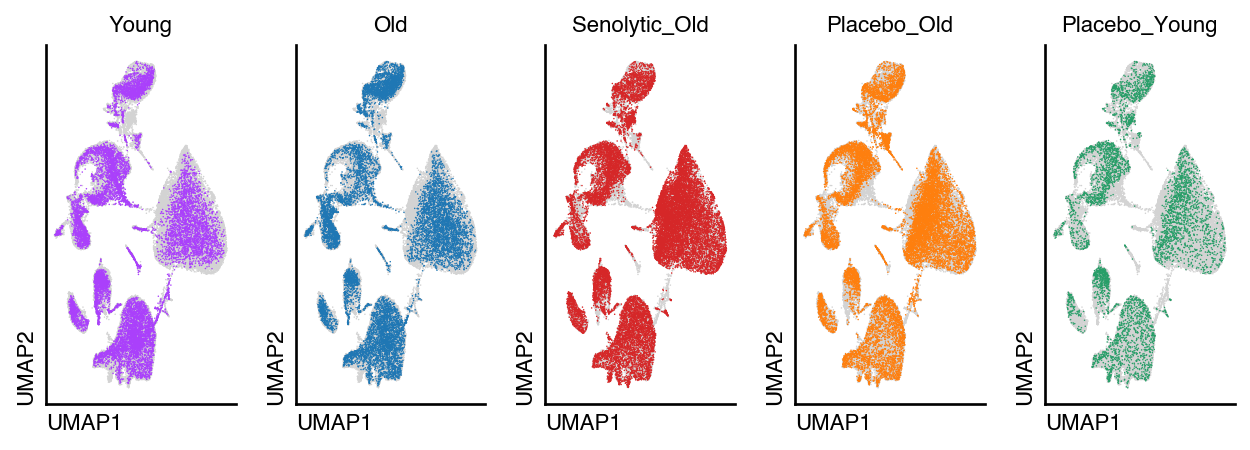

In [26]:
do.pl.split_embedding(adata_cca5, "condition",  figsize=(8, 3), ncols=5,  title_fontproperties={"size": 10},  path="/Users/david/Downloads", filename="UMAP_CCA5.pdf")

## scVI

The method scVI (single-cell Variational Inference) is a deep generative modeling framework for single-cell RNA-seq data that performs batch correction and integration by learning a shared latent representation of cells. It models gene expression counts using a hierarchical variational autoencoder, typically assuming a negative binomial (or zero-inflated negative binomial) likelihood, while explicitly conditioning on batch and other covariates. During training, scVI separates biological variation from technical effects by encoding cells into a low-dimensional latent space that is invariant to batch, while batch information is modeled in the decoder. The learned latent space can be used for visualization, clustering, and trajectory analysis, and the model enables downstream tasks such as differential expression through probabilistic inference on the original count scale. scVI is particularly effective for large, complex datasets with strong batch effects and does not require explicit feature selection, making it a flexible and scalable integration method.

In [28]:
%%time
adata_scvi = adata.copy()
do.tl.integrate_data(adata_scvi, batch_key="batch", hvg_batch=True, integration_method="scvi", categorical_covariates=["Experiment"], continuous_covariates=["total_counts"])

2026-03-11 19:43:50,843 - Computing HVGs
extracting highly variable genes
    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    with n_comps=50
    finished (0:00:13)
2026-03-11 19:44:08,632 - Integration using scVI
2026-03-11 19:44:21,983 - Run scVI


Anndata setup with scvi-tools version 1.4.0.

Setup via `SCVI.setup_anndata` with arguments:

{
│   'layer': 'counts',
│   'batch_key': 'batch',
│   'labels_key': None,
│   'size_factor_key': None,
│   'categorical_covariate_keys': ['Experiment'],
│   'continuous_covariate_keys': ['total_counts']
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │  13   │
│         n_cells          │ 64845 │
│ n_extra_categorical_covs │   1   │
│ n_extra_continuous_covs  │   1   │
│         n_labels         │   1   │
│          n_vars          │ 3677  │
└──────────────────────────┴───────┘

...

 extra_continuous_covs State 
          Registry           
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['total_counts'] │
└───────────────────────────┘

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Training:   0%|          | 0/123 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=123` reached.


2026-03-11 20:28:09,829 - Finding neighbors
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:05)
2026-03-11 20:28:15,126 - Run UMAP
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:20)
2026-03-11 20:28:35,337 - Clustering cells using Leiden (resolution 0.3)
running Leiden clustering
    finished: found 14 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)
CPU times: user 40min 41s, sys: 3min 47s, total: 44min 28s
Wall time: 44min 54s


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


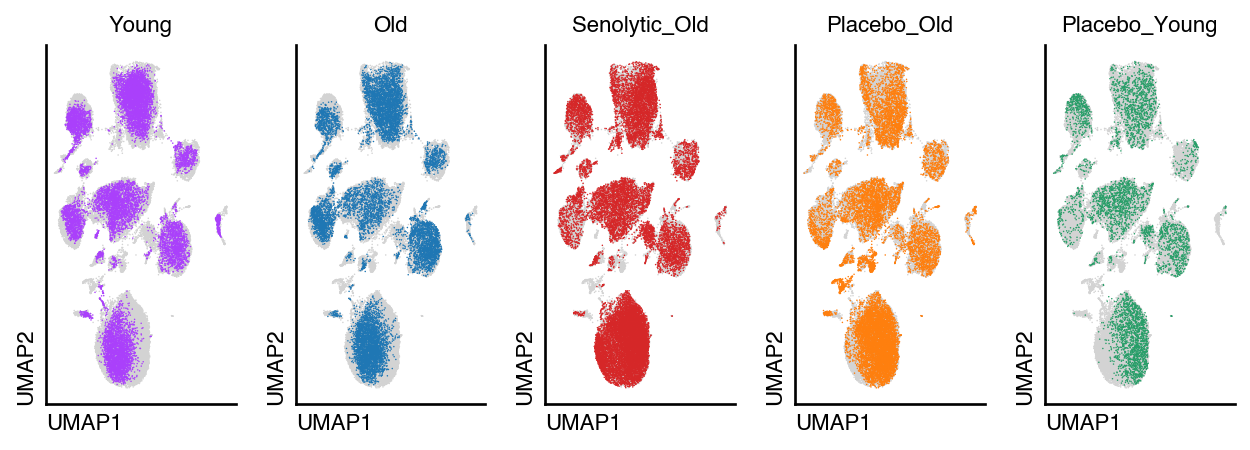

In [29]:
do.pl.split_embedding(adata_scvi, "condition",  figsize=(8, 3), ncols=5,  title_fontproperties={"size": 10},  path="/Users/david/Downloads",
                      filename="UMAP_scVI.pdf")

## Integration Comparison

We can now also compare how well the integration methods work for this dataset using the ``dotools_py.bm``, we will compute different metrics. The values are scaled between 0 and 1 with larger values indicating a better conservation of biological information.

2026-03-11 20:30:27,507 - Computing metrics for X_CCA


python(50351) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(50352) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(50367) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


computing PCA
    with n_comps=50
    finished (0:00:00)


/Users/david/miniconda3/envs/scrna_py11/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


2026-03-11 20:35:03,871 - Computing metrics for X_harmony
computing PCA
    with n_comps=50
    finished (0:00:00)


/Users/david/miniconda3/envs/scrna_py11/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


2026-03-11 20:39:28,842 - Computing metrics for X_scVI
computing PCA
    with n_comps=30
    finished (0:00:00)


/Users/david/miniconda3/envs/scrna_py11/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


2026-03-11 20:43:53,229 - Computing metrics for X_scanorama
computing PCA
    with n_comps=50
    finished (0:00:00)


/Users/david/miniconda3/envs/scrna_py11/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(
/Users/david/Desktop/ICR/PycharmProjects/DOTools_py/src/dotools_py/bm/_integration_metrics.py:445: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  main_axis.set_xticklabels(main_axis.get_xticklabels(), rotation=45, ha="right", fontweight="bold")
/Users/david/Desktop/ICR/PycharmProjects/DOTools_py/src/dotools_py/utils.py:392: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(convert_path(path) / filename, bbox_inches="tight")
1 extra bytes in post

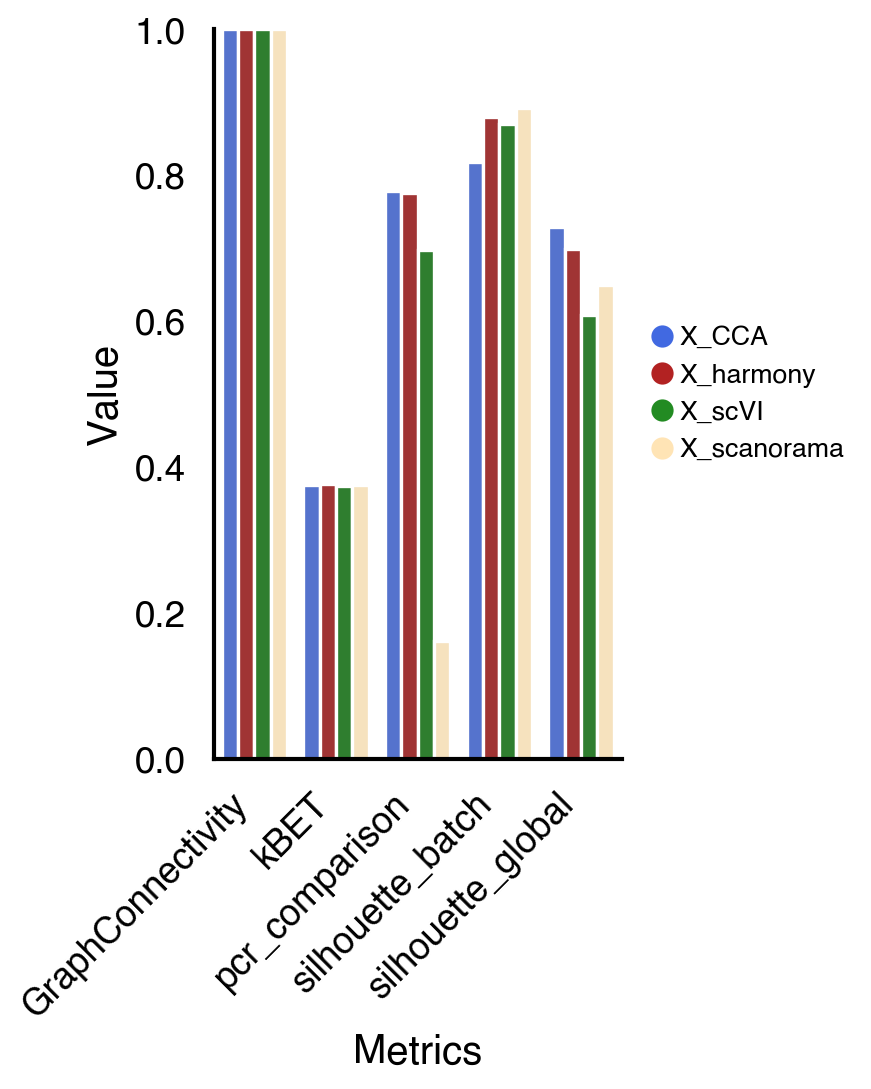

In [35]:
adata_combined = adata.copy()
adata_combined.obsm["X_CCA"] = adata_cca5.obsm["X_CCA"]
adata_combined.obsm["X_harmony"] = adata_harmony.obsm["X_harmony"]
adata_combined.obsm["X_scVI"] = adata_scvi.obsm["X_scVI"]
adata_combined.obsm["X_scanorama"] = adata_scanorama.obsm["X_scanorama"]

adata_combined.write("/Users/david/Downloads/adata_combined.h5ad")

do.utility.free_memory()

table = do.bm.eval_integration(
    adata_post=adata_combined,
    adata_pre=adata_unintegrated,
    batch_key="batch",
    annotation_key="annotation",
    use_rep=["X_CCA", "X_harmony", "X_scVI", "X_scanorama"],
    palette={"X_CCA":"royalblue", "X_harmony":"firebrick", "X_scVI":"forestgreen", "X_scanorama":"moccasin"},
    path="/Users/david/Downloads",
    filename="Barplot_EvalIntegration.pdf"
)

We can observe differences across the different metrics. For example the PCR comparison, which compare the explained variance before and after the integration, shows the highest change for `X_CCA`. On the other hand, the average silhouette for the batches shows better results for `X_scVI` and `X_harmony`.

In general, we can see similar results in this dataset for the different methods. If we inspect the UMAPs we can observed that `X_scVI`, `X_CCA`, and `X_harmony` behave similarly good. Selection of the optimal integration method normally will depend on the nature of the dataset and the computational resources available. For instance, Seurat CCA integration method might be slower compared to other methods depending on the machine it is run. scVI allows to include categorical and continuous covariate to correct for technical artifacts and would be suitable for more complex experiments. Additionally, to decrease the run time it allows the use of GPU if available. Therefore, when suboptimal results are observed is recomended to try other integration methods.

In [6]:
session_info.show(na=False, cpu=True, excludes=["backports"], std_lib=True, dependencies=True, html=True)

In [7]:
import platform
import psutil

print("OS:", platform.platform())
print("Machine:", platform.machine())
print("Processor:", platform.processor())
print("CPU cores (physical):", psutil.cpu_count(logical=False))
print("CPU cores (logical):", psutil.cpu_count(logical=True))
print("Total RAM (GB):", round(psutil.virtual_memory().total / (1024 ** 3), 2))
print("Python version:", platform.python_version())


OS: macOS-26.3.1-arm64-arm-64bit
Machine: arm64
Processor: arm
CPU cores (physical): 10
CPU cores (logical): 10
Total RAM (GB): 16.0
Python version: 3.11.13
